In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')



In [3]:
#load Dataset
customer_data = pd.read_csv('Mall_Customers.csv')
customer_data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
customer_data.shape

(200, 5)

In [5]:
customer_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
customer_data.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [7]:
customer_data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [8]:
customer_data['Gender'].value_counts()

Gender
Female    112
Male       88
Name: count, dtype: int64

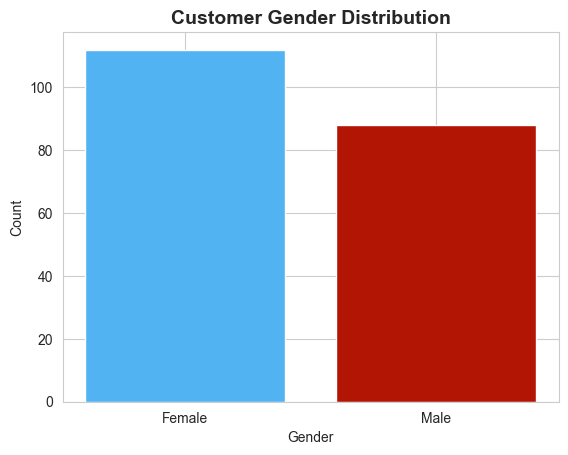

In [12]:
#gender distribution

plt.Figure(figsize=(8,5))
gender_counts = customer_data['Gender'].value_counts()
plt.bar(gender_counts.index, gender_counts.values, color=["#52b3f3","#b21503"])
plt.title('Customer Gender Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

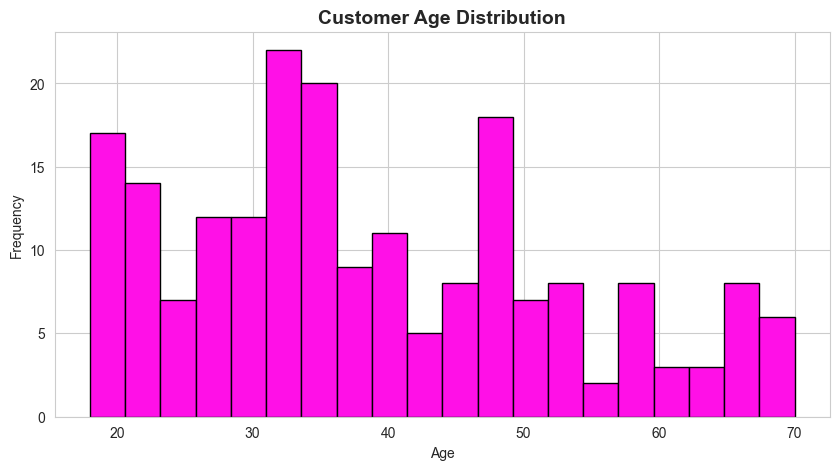

In [16]:
#AGE DISTRIBUTION

plt.figure(figsize=(10,5))
plt.hist(customer_data['Age'], bins=20, color="#ff10e7", edgecolor='black')
plt.title('Customer Age Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

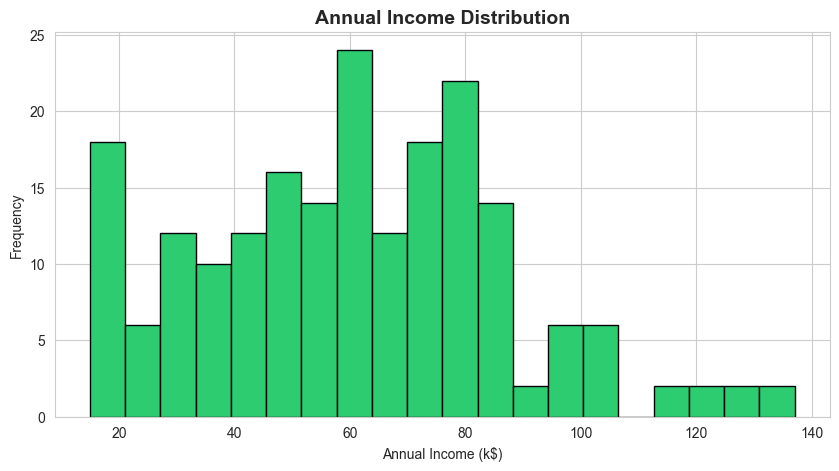

In [17]:
#annual income distribution
plt.figure(figsize=(10,5))
plt.hist(customer_data['Annual Income (k$)'], bins=20, color='#2ecc71', edgecolor='black')
plt.title('Annual Income Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Frequency')
plt.show()

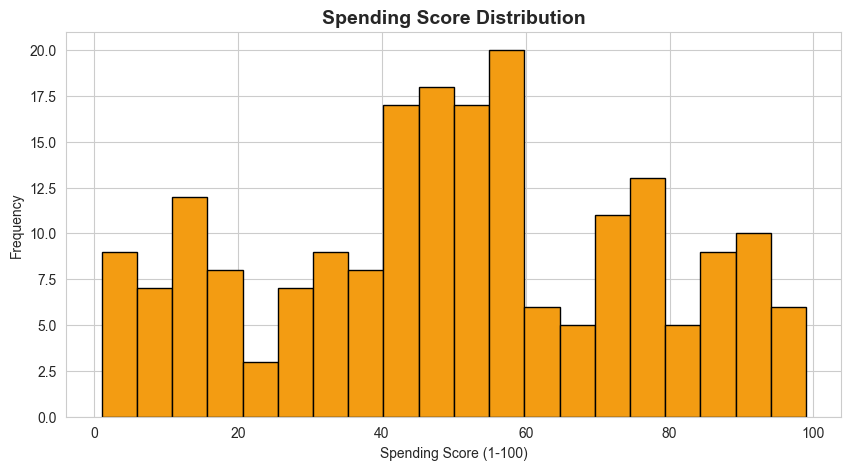

In [18]:
#spending score distribution

plt.figure(figsize=(10,5))
plt.hist(customer_data['Spending Score (1-100)'], bins=20, color='#f39c12', edgecolor='black')
plt.title('Spending Score Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Spending Score (1-100)')
plt.ylabel('Frequency')
plt.show()


In [19]:
x = customer_data.iloc[:,[3,4]].values

In [20]:
#calculate WCSS for different numbers of clusters
wcss=[]

for i in range(1,11):
    kmeans=KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)

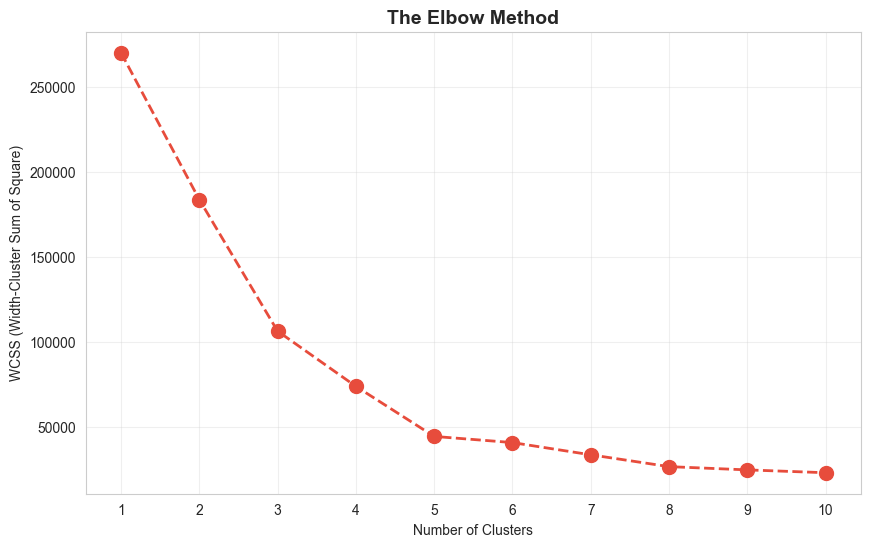

In [21]:
#plot Elow-graph

plt.figure(figsize=(10,6))
plt.plot(range(1,11), wcss, marker='o', linestyle='--', color='#e74c3c', linewidth=2, markersize=10)
plt.title('The Elbow Method', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Width-Cluster Sum of Square)')
plt.xticks(range(1,11))
plt.grid(True, alpha=0.3)
plt.show()

In [25]:
#Train with optimal clusters

kmeans=KMeans(n_clusters=5, init='k-means++', random_state=42)
y = kmeans.fit_predict(x)

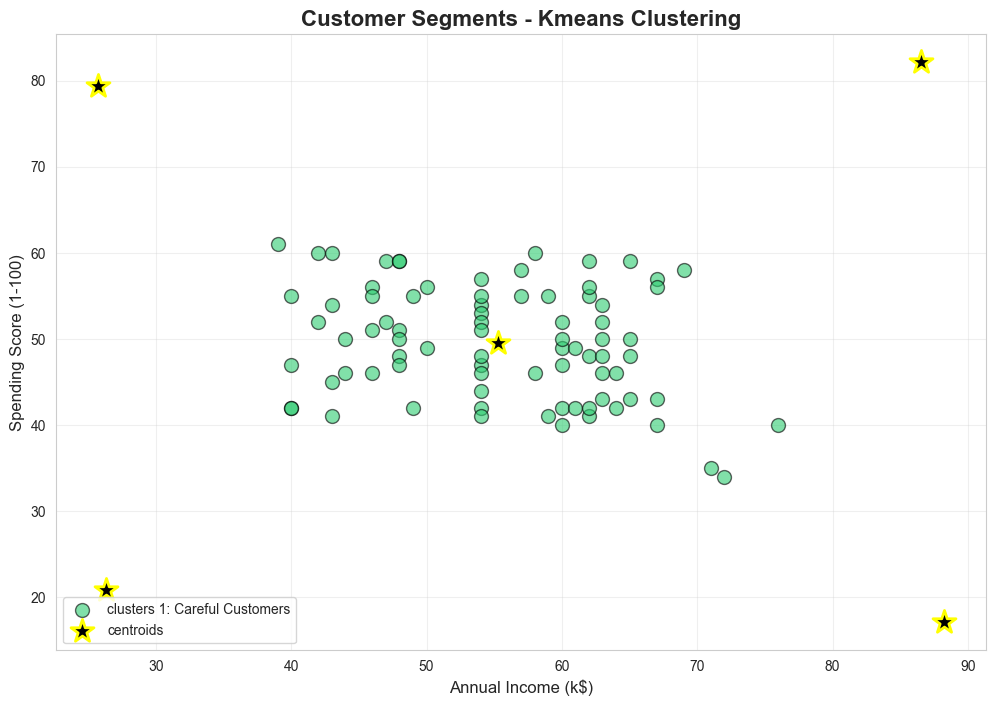

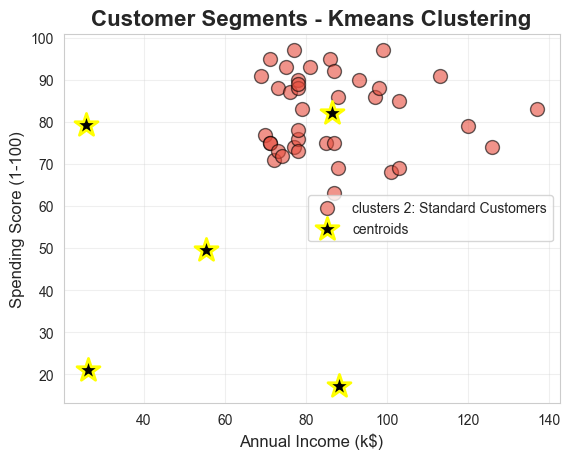

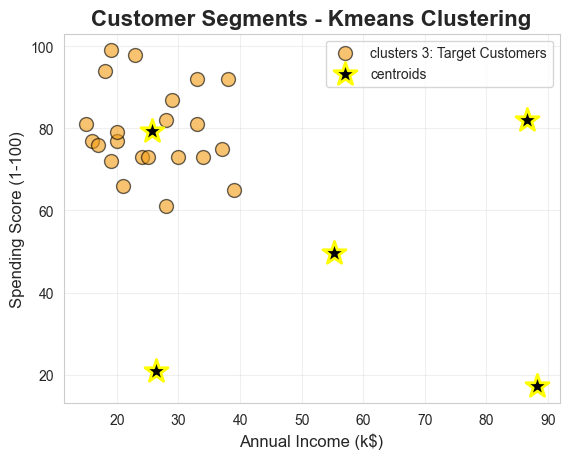

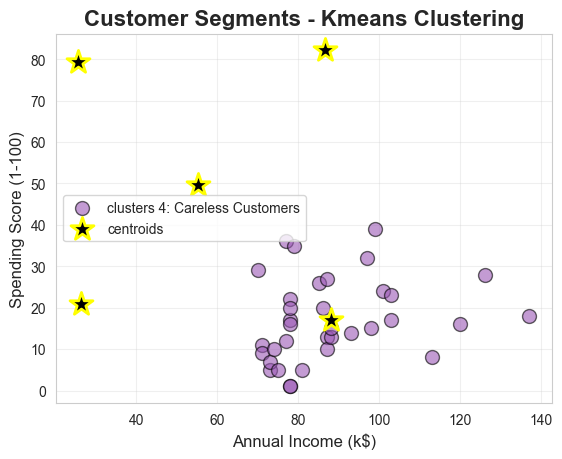

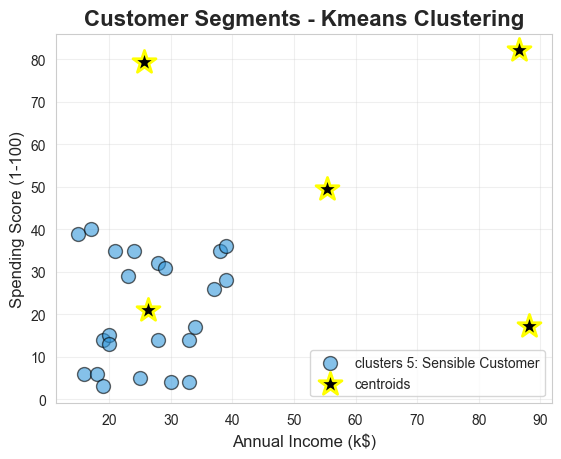

In [38]:
plt.figure(figsize=(12,8))

colors = ['#2ecc71','#e74c3c','#f39c12','#9b59b6','#3498db']
clusters_name = ['Careful Customers','Standard Customers', 'Target Customers', 'Careless Customers', 'Sensible Customer']

for i in range(5):
    plt.scatter(x[y==i, 0], x[y==i, 1], s=100, c=colors[i],
                label=f'clusters {i+1}: {clusters_name[i]}', alpha=0.6,edgecolor='black')
    plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1],
                s=300, c='black', marker='*', label='centroids', edgecolor='yellow', linewidths=2)
    
    plt.title('Customer Segments - Kmeans Clustering', fontsize=16, fontweight='bold')
    plt.xlabel('Annual Income (k$)', fontsize=12)
    plt.ylabel('Spending Score (1-100)', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True,alpha=0.3)
    plt.show()



In [29]:
customer_data['cluster']=y

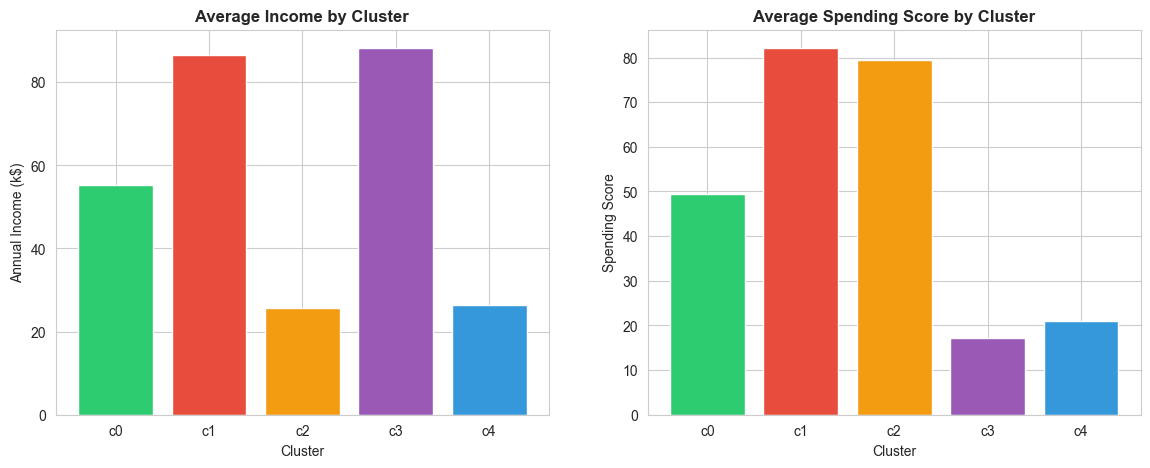

In [46]:
#create comparison visualization
fig, axes = plt.subplots(1,2, figsize=(14, 5))

#income comparison
cluster_income = [customer_data[customer_data['cluster']==i]['Annual Income (k$)'].mean()
                for i in range(5)]

axes[0].bar(range(5), cluster_income, color=colors)
axes[0].set_title('Average Income by Cluster', fontweight='bold')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Annual Income (k$)')
axes[0].set_xticks(range(5))
axes[0].set_xticklabels([f'c{i}' for i in range(5)])

#spending comaprision

cluster_spending = [customer_data[customer_data['cluster']==i]['Spending Score (1-100)'].mean()
                    for i in range(5)]
axes[1].bar(range(5), cluster_spending, color=colors)
axes[1].set_title('Average Spending Score by Cluster', fontweight='bold')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Spending Score')
axes[1].set_xticks(range(5))
axes[1].set_xticklabels([f'c{i}' for i in range(5)])

plt.show()

In [47]:
#example
new_customer = np.array([[70, 80]]) #income - 70k, spending: 80
predicted_cluster= kmeans.predict(new_customer)[0]

print(f'Customer (Income: ${new_customer[0][0]}k, spending: {new_customer[0][1]}) --cluster{predicted_cluster}: {clusters_name[predicted_cluster]}')

Customer (Income: $70k, spending: 80) --cluster1: Standard Customers


In [48]:
#save the model

joblib.dump(kmeans, 'customer_segmentation_model.pkl')
print("Model Saved")

Model Saved
